In [4]:
!pip install -q pyspark flask pyngrok kaggle

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CreditCardFraudDetection") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark Started:", spark.version)

Spark Started: 4.0.3


In [6]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:03<00:00, 20.1MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [7]:
df = spark.read.csv("creditcard.csv", header=True, inferSchema=True)
df.show(5)
print("Total rows:", df.count())
print("Total columns:", len(df.columns))

+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+
|Time|                V1|                 V2|              V3|                V4|                 V5|                 V6|                 V7|                V8|                V9|                V10|               V11|               V12|               V13|               V14|               V15|               V16|               V17|                V18|               V19|                V20|                 V21|                V22|     

In [8]:
df.printSchema()

root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: double (nullable = true)
 |-- V28: double (nulla

In [9]:
df.createOrReplaceTempView("transactions")

class_dist = spark.sql("""
    SELECT Class, COUNT(*) as count,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM transactions), 4) as pct
    FROM transactions
    GROUP BY Class
""")
class_dist.show()

+-----+------+-------+
|Class| count|    pct|
+-----+------+-------+
|    1|   492| 0.1727|
|    0|284315|99.8273|
+-----+------+-------+



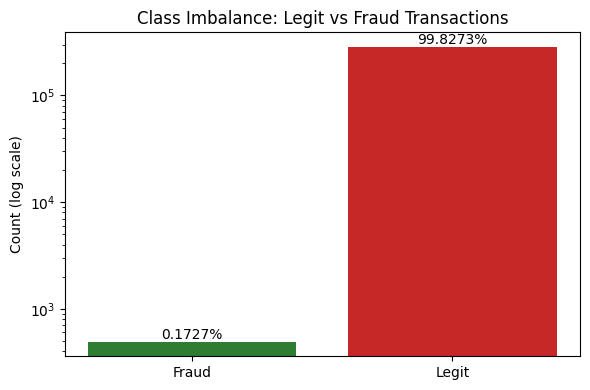

In [10]:
import matplotlib.pyplot as plt

pdf_dist = class_dist.toPandas()
labels = ["Legit" if c == 0 else "Fraud" for c in pdf_dist["Class"]]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, pdf_dist["count"], color=["#2E7D32", "#C62828"])
plt.yscale("log")
plt.ylabel("Count (log scale)")
plt.title("Class Imbalance: Legit vs Fraud Transactions")
for bar, pct in zip(bars, pdf_dist["pct"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{pct}%",
             ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("class_imbalance.png", dpi=150)
plt.show()

In [11]:
amount_stats = spark.sql("""
    SELECT Class,
           ROUND(AVG(Amount), 2) as avg_amount,
           ROUND(MIN(Amount), 2) as min_amount,
           ROUND(MAX(Amount), 2) as max_amount
    FROM transactions
    GROUP BY Class
""")
amount_stats.show()

+-----+----------+----------+----------+
|Class|avg_amount|min_amount|max_amount|
+-----+----------+----------+----------+
|    1|    122.21|       0.0|   2125.87|
|    0|     88.29|       0.0|  25691.16|
+-----+----------+----------+----------+



In [12]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

feature_cols = [c for c in df.columns if c not in ("Class",)]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withMean=True, withStd=True)

prep_pipeline = Pipeline(stages=[assembler, scaler])
prep_model = prep_pipeline.fit(df)
data = prep_model.transform(df)

data.select("features", "Class").show(5, truncate=80)

+--------------------------------------------------------------------------------+-----+
|                                                                        features|Class|
+--------------------------------------------------------------------------------+-----+
|[-1.9965795183032182,-0.6942411021638862,-0.04407484719355174,1.6727705625425...|    0|
|[-1.9965795183032182,0.6084952594310943,0.1611756369266402,0.1097969093488265...|    0|
|[-1.9965584604164572,-0.6934992452238201,-0.8115764015230564,1.16946643973207...|    0|
|[-1.9965584604164572,-0.4933240320774146,-0.11216922771730702,1.1825143748616...|    0|
|[-1.9965374025296962,-0.5913287255806585,0.5315401165822377,1.021409882389417...|    0|
+--------------------------------------------------------------------------------+-----+
only showing top 5 rows


In [13]:
from pyspark.sql import functions as F

total = data.count()
fraud_count = data.filter(F.col("Class") == 1).count()
legit_count = total - fraud_count

weight_fraud = total / (2.0 * fraud_count)
weight_legit = total / (2.0 * legit_count)

print(f"Legit weight: {weight_legit:.4f}  |  Fraud weight: {weight_fraud:.4f}")

data = data.withColumn(
    "classWeight",
    F.when(F.col("Class") == 1, weight_fraud).otherwise(weight_legit)
)

Legit weight: 0.5009  |  Fraud weight: 289.4380


In [14]:
train, test = data.randomSplit([0.8, 0.2], seed=42)
print("Train rows:", train.count(), " | Test rows:", test.count())
print("Train fraud count:", train.filter(F.col('Class')==1).count())
print("Test fraud count:", test.filter(F.col('Class')==1).count())

Train rows: 227834  | Test rows: 56973
Train fraud count: 394
Test fraud count: 98


In [15]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

pr_evaluator = BinaryClassificationEvaluator(labelCol="Class", metricName="areaUnderPR")
roc_evaluator = BinaryClassificationEvaluator(labelCol="Class", metricName="areaUnderROC")
f1_evaluator = MulticlassClassificationEvaluator(labelCol="Class", metricName="f1")
precision_evaluator = MulticlassClassificationEvaluator(labelCol="Class", metricName="weightedPrecision")
recall_evaluator = MulticlassClassificationEvaluator(labelCol="Class", metricName="weightedRecall")

def evaluate_model(predictions, name):
    metrics = {
        "Model": name,
        "PR-AUC": round(pr_evaluator.evaluate(predictions), 4),
        "ROC-AUC": round(roc_evaluator.evaluate(predictions), 4),
        "F1": round(f1_evaluator.evaluate(predictions), 4),
        "Precision": round(precision_evaluator.evaluate(predictions), 4),
        "Recall": round(recall_evaluator.evaluate(predictions), 4),
    }
    return metrics

results = []

In [16]:
lr = LogisticRegression(labelCol="Class", featuresCol="features", weightCol="classWeight", maxIter=50)
lr_model = lr.fit(train)
lr_preds = lr_model.transform(test)
results.append(evaluate_model(lr_preds, "Logistic Regression"))
print(results[-1])

{'Model': 'Logistic Regression', 'PR-AUC': 0.6982, 'ROC-AUC': 0.9744, 'F1': 0.9888, 'Precision': 0.9982, 'Recall': 0.9808}


In [17]:
rf = RandomForestClassifier(labelCol="Class", featuresCol="features", weightCol="classWeight",
                             numTrees=100, maxDepth=8, seed=42)
rf_model = rf.fit(train)
rf_preds = rf_model.transform(test)
results.append(evaluate_model(rf_preds, "Random Forest"))
print(results[-1])

{'Model': 'Random Forest', 'PR-AUC': 0.765, 'ROC-AUC': 0.9848, 'F1': 0.9991, 'Precision': 0.9991, 'Recall': 0.9991}


In [18]:
gbt = GBTClassifier(labelCol="Class", featuresCol="features", maxIter=50, maxDepth=5, seed=42)
gbt_model = gbt.fit(train)
gbt_preds = gbt_model.transform(test)
results.append(evaluate_model(gbt_preds, "Gradient-Boosted Trees"))
print(results[-1])

{'Model': 'Gradient-Boosted Trees', 'PR-AUC': 0.8119, 'ROC-AUC': 0.9762, 'F1': 0.9995, 'Precision': 0.9995, 'Recall': 0.9995}


In [19]:
import pandas as pd

results_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,PR-AUC,ROC-AUC,F1,Precision,Recall
0,Gradient-Boosted Trees,0.8119,0.9762,0.9995,0.9995,0.9995
1,Random Forest,0.7650,0.9848,0.9991,0.9991,0.9991
2,Logistic Regression,0.6982,0.9744,0.9888,0.9982,0.9808


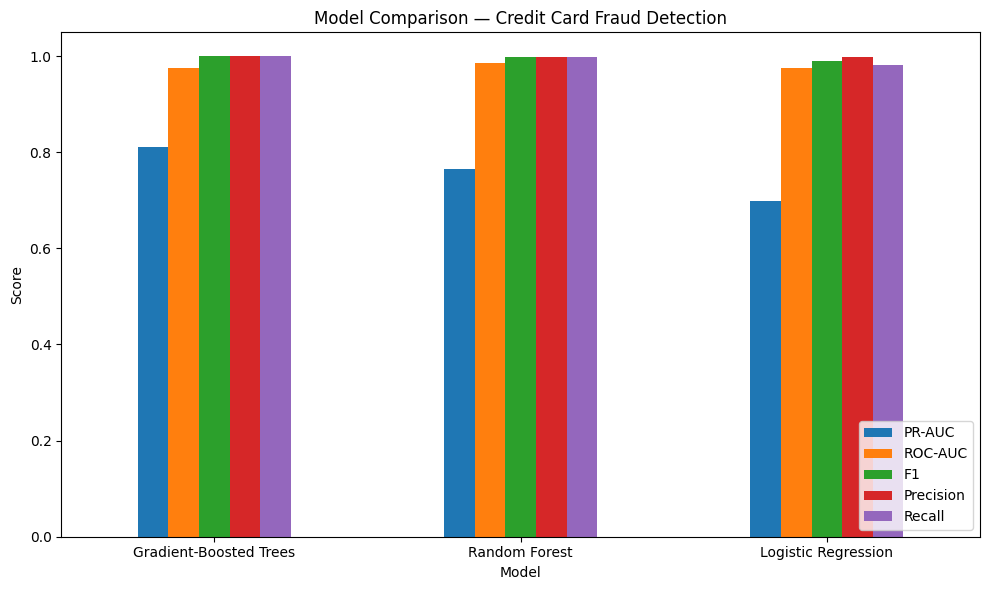

In [20]:
metrics_to_plot = ["PR-AUC", "ROC-AUC", "F1", "Precision", "Recall"]
ax = results_df.set_index("Model")[metrics_to_plot].plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison — Credit Card Fraud Detection")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

In [21]:
best_row = results_df.iloc[0]
print(f"Best model: {best_row['Model']} (PR-AUC = {best_row['PR-AUC']})")

model_map = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient-Boosted Trees": gbt_model
}
best_model = model_map[best_row["Model"]]
from pyspark.ml import PipelineModel

full_pipeline = PipelineModel(stages=[prep_model.stages[0], prep_model.stages[1]])
full_pipeline.write().overwrite().save("/content/prep_pipeline")
best_model.write().overwrite().save("/content/best_fraud_model")
print("Saved preprocessing pipeline and best model to /content/")

Best model: Gradient-Boosted Trees (PR-AUC = 0.8119)
Saved preprocessing pipeline and best model to /content/


## 6. Deployment — Flask API

In [22]:
from pyspark.ml import PipelineModel
from pyspark.ml.classification import RandomForestClassificationModel, LogisticRegressionModel, GBTClassificationModel
loaded_pipeline = PipelineModel.load("/content/prep_pipeline")
model_classes = {
    "Logistic Regression": LogisticRegressionModel,
    "Random Forest": RandomForestClassificationModel,
    "Gradient-Boosted Trees": GBTClassificationModel
}
loaded_model = model_classes[best_row["Model"]].load("/content/best_fraud_model")
print("Model reloaded successfully for serving.")

Model reloaded successfully for serving.


In [23]:
import numpy as np

test_scored = loaded_model.transform(test)
test_probs_pdf = test_scored.select("Class", "Amount", "probability").toPandas()
test_probs_pdf["fraud_probability"] = test_probs_pdf["probability"].apply(lambda p: float(p[1]))
test_probs_pdf = test_probs_pdf[["Class", "Amount", "fraud_probability"]]

avg_fraud_amount = float(train.filter(F.col("Class") == 1).agg(F.avg("Amount")).collect()[0][0])
INVESTIGATION_COST = 5.0
print(f"Test set probabilities precomputed: {len(test_probs_pdf)} rows")
print(f"Average fraud transaction amount (used as missed-fraud cost): ${avg_fraud_amount:.2f}")

Test set probabilities precomputed: 56973 rows
Average fraud transaction amount (used as missed-fraud cost): $117.99


In [24]:
def compute_confusion(threshold):
    predicted_fraud = test_probs_pdf["fraud_probability"] >= threshold
    actual_fraud = test_probs_pdf["Class"] == 1
    tp = int((predicted_fraud & actual_fraud).sum())
    fp = int((predicted_fraud & ~actual_fraud).sum())
    fn = int((~predicted_fraud & actual_fraud).sum())
    tn = int((~predicted_fraud & ~actual_fraud).sum())
    return tp, fp, fn, tn

def compute_cost(threshold):
    tp, fp, fn, tn = compute_confusion(threshold)
    investigation_total = (tp + fp) * INVESTIGATION_COST
    missed_fraud_cost = fn * avg_fraud_amount
    return investigation_total + missed_fraud_cost

threshold_grid = np.arange(0.01, 1.0, 0.01)
sweep_points = [{"threshold": round(float(t), 2), "net_cost": round(compute_cost(t), 2)} for t in threshold_grid]
best_threshold = min(sweep_points, key=lambda p: p["net_cost"])
print(f"Lowest-cost threshold found: {best_threshold['threshold']} (net cost ${best_threshold['net_cost']:,.2f})")
print(f"For comparison, net cost at default 0.5 threshold: ${compute_cost(0.5):,.2f}")

Lowest-cost threshold found: 0.05 (net cost $2,778.89)
For comparison, net cost at default 0.5 threshold: $3,442.84


In [25]:
legit_avgs_row = train.filter(F.col("Class") == 0).select(feature_cols).groupBy().avg().collect()[0]
legit_means_dict = {c: legit_avgs_row[f"avg({c})"] for c in feature_cols}
legit_means_array = np.array([legit_means_dict[c] for c in feature_cols])

if best_row["Model"] == "Logistic Regression":
    explain_weights = np.array(lr_model.coefficients.toArray())
    explain_mode = "signed_scaled"
else:
    explain_weights = np.array(best_model.featureImportances.toArray())
    explain_mode = "importance_deviation"

print("Explainability mode:", explain_mode)

Explainability mode: importance_deviation


In [26]:
DASHBOARD_HTML = r"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Fraud Review Desk</title>
<meta name="viewport" content="width=device-width, initial-scale=1">
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Source+Serif+4:opsz,wght@8..60,500;8..60,700&family=Inter:wght@400;500;600&family=IBM+Plex+Mono:wght@400;500;600&display=swap" rel="stylesheet">
<style>
  :root{
    --ink-950:#0B1220;
    --ink-900:#101B30;
    --ink-800:#1B2740;
    --ink-700:#2A3752;
    --paper:#E9ECF3;
    --muted:#8A96B2;
    --gold:#C9A227;
    --gold-dim:#8f7220;
    --alert:#D64550;
    --clear:#2E9E83;
  }
  *{box-sizing:border-box;}
  body{
    margin:0;
    background:
      radial-gradient(1200px 600px at 80% -10%, rgba(201,162,39,0.08), transparent),
      var(--ink-950);
    color:var(--paper);
    font-family:'Inter',sans-serif;
    min-height:100vh;
  }
  .letterhead{ padding:36px 48px 20px 48px; border-bottom:1px solid var(--ink-700); }
  .letterhead .eyebrow{ font-family:'IBM Plex Mono',monospace; font-size:12px; letter-spacing:.14em; color:var(--gold); text-transform:uppercase; }
  .letterhead h1{ font-family:'Source Serif 4',serif; font-weight:700; font-size:34px; margin:6px 0 8px 0; letter-spacing:.01em; }
  .letterhead .meta{ font-family:'IBM Plex Mono',monospace; font-size:13px; color:var(--muted); }
  .meta b{color:var(--paper); font-weight:500;}
  .tabs{ display:flex; gap:2px; padding:0 48px; margin-top:22px; flex-wrap:wrap; }
  .tab-btn{
    font-family:'IBM Plex Mono',monospace; font-size:13px; letter-spacing:.05em; text-transform:uppercase;
    background:var(--ink-900); color:var(--muted); border:1px solid var(--ink-700); border-bottom:none;
    padding:12px 20px; cursor:pointer; border-radius:6px 6px 0 0; transition:color .15s ease, background .15s ease;
  }
  .tab-btn.active{ background:var(--ink-800); color:var(--gold); }
  .tab-btn:hover:not(.active){ color:var(--paper); }
  main{ padding:0 48px 60px 48px; }
  .panel{ background:var(--ink-800); border:1px solid var(--ink-700); border-radius:0 8px 8px 8px; padding:32px; min-height:360px; }
  .panel-hidden{ display:none; }
  h2.section-title{ font-family:'Source Serif 4',serif; font-size:20px; font-weight:600; margin:0 0 6px 0; }
  p.section-desc{ color:var(--muted); font-size:14px; margin:0 0 24px 0; max-width:680px; line-height:1.5; }
  select, input[type=file]{
    font-family:'IBM Plex Mono',monospace; background:var(--ink-900); color:var(--paper);
    border:1px solid var(--ink-700); border-radius:6px; padding:10px 14px; font-size:13px; width:100%; max-width:520px;
  }
  button.action{
    font-family:'IBM Plex Mono',monospace; text-transform:uppercase; letter-spacing:.06em; font-size:12px;
    background:var(--gold); color:var(--ink-950); border:none; border-radius:6px; padding:12px 22px;
    margin-top:16px; cursor:pointer; font-weight:600; transition:background .15s ease;
  }
  button.action:hover{ background:#e0b830; }
  button.action:disabled{ background:var(--ink-700); color:var(--muted); cursor:not-allowed; }
  button.mini{
    font-family:'IBM Plex Mono',monospace; font-size:11px; text-transform:uppercase; letter-spacing:.04em;
    border-radius:4px; padding:5px 10px; cursor:pointer; border:1px solid; margin-right:6px; background:transparent;
  }
  button.mini.confirm{ color:var(--alert); border-color:var(--alert); }
  button.mini.confirm:hover{ background:rgba(214,69,80,0.12); }
  button.mini.dismiss{ color:var(--clear); border-color:var(--clear); }
  button.mini.dismiss:hover{ background:rgba(46,158,131,0.12); }
  button.mini:disabled{ opacity:0.35; cursor:not-allowed; }

  .review-grid{ display:grid; grid-template-columns: 1.1fr 0.9fr; gap:36px; align-items:start; }
  .result-box{ display:flex; flex-direction:column; align-items:center; justify-content:center; min-height:220px; border:1px dashed var(--ink-700); border-radius:8px; padding:20px; }
  .stamp{
    font-family:'Source Serif 4',serif; font-weight:700; font-size:30px; letter-spacing:.08em; text-transform:uppercase;
    padding:10px 26px; border:4px double; border-radius:4px; display:inline-block; opacity:0.92;
  }
  .stamp.fraud{ color:var(--alert); border-color:var(--alert); transform:rotate(-6deg); }
  .stamp.clear{ color:var(--clear); border-color:var(--clear); transform:rotate(4deg); }
  .stamp-meta{ font-family:'IBM Plex Mono',monospace; font-size:13px; color:var(--muted); margin-top:18px; text-align:center; line-height:1.6; }
  .stamp-meta .correct{ color:var(--clear); }
  .stamp-meta .wrong{ color:var(--alert); }

  .contrib-list{ margin-top:20px; width:100%; max-width:340px; }
  .contrib-row{ display:flex; align-items:center; gap:8px; font-family:'IBM Plex Mono',monospace; font-size:12px; margin-bottom:6px; }
  .contrib-name{ width:60px; color:var(--muted); flex-shrink:0; }
  .contrib-bar-wrap{ flex:1; background:var(--ink-900); border-radius:3px; height:10px; position:relative; overflow:hidden; }
  .contrib-bar{ position:absolute; top:0; bottom:0; }
  .contrib-bar.pos{ background:var(--alert); right:50%; }
  .contrib-bar.neg{ background:var(--clear); left:50%; }
  .contrib-mid{ position:absolute; left:50%; top:0; bottom:0; width:1px; background:var(--ink-700); }

  table{ width:100%; border-collapse:collapse; font-family:'IBM Plex Mono',monospace; font-size:12.5px; margin-top:18px; }
  th,td{ text-align:left; padding:8px 10px; border-bottom:1px solid var(--ink-700); }
  th{ color:var(--gold); font-weight:600; text-transform:uppercase; letter-spacing:.05em; font-size:11px;}
  td.fraud-row{ color:var(--alert); }
  td.legit-row{ color:var(--clear); }
  .decision-tag{ font-size:11px; padding:2px 6px; border-radius:3px; }
  .decision-tag.confirmed_fraud{ color:var(--alert); border:1px solid var(--alert); }
  .decision-tag.false_positive{ color:var(--clear); border:1px solid var(--clear); }

  .summary-line{ font-family:'IBM Plex Mono',monospace; font-size:14px; color:var(--paper); margin:6px 0; }
  .summary-line b{ color:var(--gold); }
  .download-link{ display:inline-block; margin-top:14px; color:var(--gold); font-family:'IBM Plex Mono',monospace; font-size:13px; text-decoration:none; border-bottom:1px dotted var(--gold); }

  .metric-grid{ display:grid; grid-template-columns:repeat(auto-fit,minmax(150px,1fr)); gap:14px; margin-top:8px; }
  .metric-card{ background:var(--ink-900); border:1px solid var(--ink-700); border-radius:8px; padding:16px; }
  .metric-card .label{ font-family:'IBM Plex Mono',monospace; font-size:11px; color:var(--muted); text-transform:uppercase; letter-spacing:.06em;}
  .metric-card .value{ font-family:'Source Serif 4',serif; font-size:24px; font-weight:700; color:var(--gold); margin-top:4px;}
  .charts{ display:flex; gap:24px; margin-top:28px; flex-wrap:wrap; }
  .charts img{ max-width:460px; width:100%; border:1px solid var(--ink-700); border-radius:8px; }
  .loading{ color:var(--muted); font-family:'IBM Plex Mono',monospace; font-size:13px; }

  .slider-row{ display:flex; align-items:center; gap:18px; max-width:640px; }
  input[type=range]{ flex:1; accent-color:var(--gold); }
  .threshold-val{ font-family:'IBM Plex Mono',monospace; color:var(--gold); font-size:18px; min-width:60px; text-align:right; }
  .cost-note{ font-family:'IBM Plex Mono',monospace; font-size:12px; color:var(--muted); margin-top:10px; max-width:640px; line-height:1.5; }
  canvas#sweep-chart{ margin-top:24px; border:1px solid var(--ink-700); border-radius:8px; background:var(--ink-900); }
</style>
</head>
<body>

<div class="letterhead">
  <div class="eyebrow">Case file &middot; Credit Card Fraud Detection</div>
  <h1>Fraud Review Desk</h1>
  <div class="meta">Model on duty: <b id="model-name">—</b> &nbsp;|&nbsp; PR-AUC: <b id="model-prauc">—</b> &nbsp;|&nbsp; ROC-AUC: <b id="model-rocauc">—</b></div>
</div>

<div class="tabs">
  <button class="tab-btn active" data-tab="review">Single Review</button>
  <button class="tab-btn" data-tab="batch">Batch Report</button>
  <button class="tab-btn" data-tab="threshold">Threshold &amp; Cost</button>
  <button class="tab-btn" data-tab="log">Review Log</button>
  <button class="tab-btn" data-tab="performance">Performance</button>
</div>

<main>
  <section id="tab-review" class="panel">
    <h2 class="section-title">Single Transaction Review</h2>
    <p class="section-desc">Pull a real transaction from the test set and see the model's call against the true label, plus which features drove the decision.</p>
    <div class="review-grid">
      <div>
        <select id="txn-select"><option>Loading transactions…</option></select><br>
        <button class="action" id="score-btn">Score this transaction</button>
      </div>
      <div class="result-box" id="result-box">
        <span class="loading">Select a transaction and press score.</span>
      </div>
    </div>
  </section>

  <section id="tab-batch" class="panel panel-hidden">
    <h2 class="section-title">Batch Scoring &amp; Risk Report</h2>
    <p class="section-desc">Upload a CSV with columns Time, V1…V28, Amount. Results are sorted highest-risk first — the order an analyst would actually work through them — with total dollar amount at risk and one-click review actions.</p>
    <input type="file" id="batch-file" accept=".csv"><br>
    <button class="action" id="batch-btn">Score batch</button>
    <div id="batch-summary" style="margin-top:20px;"></div>
    <div id="batch-table-wrap"></div>
  </section>

  <section id="tab-threshold" class="panel panel-hidden">
    <h2 class="section-title">Threshold &amp; Cost Analysis</h2>
    <p class="section-desc">The default 50% cutoff is arbitrary. Move the slider to see how precision, recall, and estimated business cost shift at other thresholds, computed against the actual test set.</p>
    <div class="slider-row">
      <input type="range" id="threshold-slider" min="1" max="99" value="50">
      <span class="threshold-val" id="threshold-val">0.50</span>
    </div>
    <div class="metric-grid" id="threshold-metrics" style="margin-top:24px;"></div>
    <div class="cost-note" id="cost-note"></div>
    <canvas id="sweep-chart" width="640" height="180"></canvas>
  </section>

  <section id="tab-log" class="panel panel-hidden">
    <h2 class="section-title">Review Log</h2>
    <p class="section-desc">Decisions made from the Batch Report tab, simulating the feedback loop a real fraud team would log back into the system.</p>
    <div class="metric-grid" id="log-summary"></div>
    <div id="log-table-wrap"></div>
  </section>

  <section id="tab-performance" class="panel panel-hidden">
    <h2 class="section-title">Model Performance</h2>
    <p class="section-desc">How the chosen model compares against the alternatives that were trained and evaluated.</p>
    <div class="metric-grid" id="metric-grid"><span class="loading">Loading metrics…</span></div>
    <div class="charts" id="charts"></div>
  </section>
</main>

<script>
const tabs = document.querySelectorAll(".tab-btn");
const panels = { review: document.getElementById("tab-review"),
                 batch: document.getElementById("tab-batch"),
                 threshold: document.getElementById("tab-threshold"),
                 log: document.getElementById("tab-log"),
                 performance: document.getElementById("tab-performance") };

tabs.forEach(btn => btn.addEventListener("click", () => {
  tabs.forEach(b => b.classList.remove("active"));
  btn.classList.add("active");
  Object.values(panels).forEach(p => p.classList.add("panel-hidden"));
  panels[btn.dataset.tab].classList.remove("panel-hidden");
  if (btn.dataset.tab === "performance") loadPerformance();
  if (btn.dataset.tab === "threshold") loadThresholdTab();
  if (btn.dataset.tab === "log") loadReviewLog();
}));

async function loadSamples(){
  const res = await fetch("/api/samples");
  const data = await res.json();
  const sel = document.getElementById("txn-select");
  sel.innerHTML = "";
  data.samples.forEach(s => {
    const opt = document.createElement("option");
    opt.value = s.index;
    opt.textContent = s.label;
    sel.appendChild(opt);
  });
  document.getElementById("model-name").textContent = data.model_name;
  document.getElementById("model-prauc").textContent = data.pr_auc;
  document.getElementById("model-rocauc").textContent = data.roc_auc;
}

function renderContributions(features){
  const maxAbs = Math.max(...features.map(f => Math.abs(f.contribution)), 1e-9);
  return features.map(f => {
    const pct = Math.min(Math.abs(f.contribution) / maxAbs * 50, 50);
    const cls = f.contribution >= 0 ? "pos" : "neg";
    const style = cls === "pos" ? `width:${pct}%;` : `width:${pct}%;`;
    return `
      <div class="contrib-row">
        <div class="contrib-name">${f.feature}</div>
        <div class="contrib-bar-wrap">
          <div class="contrib-mid"></div>
          <div class="contrib-bar ${cls}" style="${style}"></div>
        </div>
      </div>`;
  }).join("");
}

document.getElementById("score-btn").addEventListener("click", async () => {
  const idx = document.getElementById("txn-select").value;
  const box = document.getElementById("result-box");
  box.innerHTML = '<span class="loading">Scoring…</span>';
  const res = await fetch("/api/score", {
    method: "POST",
    headers: {"Content-Type": "application/json"},
    body: JSON.stringify({index: idx})
  });
  const data = await res.json();
  const stampClass = data.prediction === "FRAUD" ? "fraud" : "clear";
  const stampText = data.prediction === "FRAUD" ? "Fraud" : "Cleared";
  const correctClass = data.correct ? "correct" : "wrong";
  const correctText = data.correct ? "Model call matches true label" : "Model missed this one";
  box.innerHTML = `
    <div class="stamp ${stampClass}">${stampText}</div>
    <div class="stamp-meta">
      Fraud probability: <b>${(data.fraud_probability*100).toFixed(2)}%</b><br>
      Amount: $${data.amount.toFixed(2)} &middot; True label: ${data.true_label}<br>
      <span class="${correctClass}">${correctText}</span>
    </div>
    <div class="contrib-list">
      <div style="font-family:'IBM Plex Mono',monospace;font-size:11px;color:var(--muted);text-transform:uppercase;letter-spacing:.05em;margin-bottom:8px;">Top contributing features (red = toward fraud)</div>
      ${renderContributions(data.top_features)}
    </div>`;
});

let currentBatchRows = [];

document.getElementById("batch-btn").addEventListener("click", async () => {
  const fileInput = document.getElementById("batch-file");
  if (!fileInput.files.length){ alert("Choose a CSV file first."); return; }
  const summaryEl = document.getElementById("batch-summary");
  const tableEl = document.getElementById("batch-table-wrap");
  summaryEl.innerHTML = '<span class="loading">Scoring batch…</span>';
  tableEl.innerHTML = "";

  const form = new FormData();
  form.append("file", fileInput.files[0]);
  const res = await fetch("/api/batch", { method: "POST", body: form });
  const data = await res.json();

  if (data.error){
    summaryEl.innerHTML = `<span style="color:var(--alert)">${data.error}</span>`;
    return;
  }

  currentBatchRows = data.rows;

  summaryEl.innerHTML = `
    <div class="summary-line">Transactions scored: <b>${data.total}</b></div>
    <div class="summary-line">Flagged as fraud: <b>${data.flagged} (${data.flagged_pct}%)</b></div>
    <div class="summary-line">Total amount at risk: <b>$${data.amount_at_risk}</b></div>
    <a class="download-link" href="/api/download" download>Download full results (CSV)</a>
  `;
  renderBatchTable();
});

function renderBatchTable(){
  const tableEl = document.getElementById("batch-table-wrap");
  let rows = currentBatchRows.map(r => {
    const isFraud = r.predicted_label === 'FRAUD';
    const actions = isFraud ? `
      <button class="mini confirm" data-rowid="${r.row_id}" data-decision="confirmed_fraud">Confirm</button>
      <button class="mini dismiss" data-rowid="${r.row_id}" data-decision="false_positive">False Pos.</button>
      <span class="decision-out" data-rowid-out="${r.row_id}"></span>` : "—";
    return `
      <tr>
        <td>${r.Time}</td>
        <td>$${Number(r.Amount).toFixed(2)}</td>
        <td class="${isFraud ? 'fraud-row' : 'legit-row'}">${r.predicted_label}</td>
        <td>${(r.fraud_probability*100).toFixed(2)}%</td>
        <td>${actions}</td>
      </tr>`;
  }).join("");
  tableEl.innerHTML = `
    <table>
      <tr><th>Time</th><th>Amount</th><th>Verdict</th><th>Fraud Prob.</th><th>Review</th></tr>
      ${rows}
    </table>`;

  tableEl.querySelectorAll("button.mini").forEach(btn => {
    btn.addEventListener("click", async () => {
      const rowId = btn.dataset.rowid;
      const decision = btn.dataset.decision;
      const row = currentBatchRows.find(r => String(r.row_id) === String(rowId));
      await fetch("/api/review", {
        method: "POST",
        headers: {"Content-Type": "application/json"},
        body: JSON.stringify({
          row_id: rowId, amount: row.Amount,
          predicted_label: row.predicted_label, decision: decision
        })
      });
      const out = tableEl.querySelector(`.decision-out[data-rowid-out="${rowId}"]`);
      out.innerHTML = `<span class="decision-tag ${decision}">${decision === "confirmed_fraud" ? "Confirmed" : "False positive"}</span>`;
      const parent = btn.parentElement;
      parent.querySelectorAll("button.mini").forEach(b => b.disabled = true);
    });
  });
}

let sweepData = null;

async function loadThresholdTab(){
  await updateThreshold(0.5);
  if (!sweepData){
    const res = await fetch("/api/threshold_sweep");
    sweepData = await res.json();
    drawSweepChart(0.5);
  }
}

async function updateThreshold(t){
  const res = await fetch(`/api/threshold?threshold=${t}`);
  const data = await res.json();
  const grid = document.getElementById("threshold-metrics");
  grid.innerHTML = `
    <div class="metric-card"><div class="label">Precision</div><div class="value">${(data.precision*100).toFixed(1)}%</div></div>
    <div class="metric-card"><div class="label">Recall</div><div class="value">${(data.recall*100).toFixed(1)}%</div></div>
    <div class="metric-card"><div class="label">F1</div><div class="value">${(data.f1*100).toFixed(1)}%</div></div>
    <div class="metric-card"><div class="label">Flagged</div><div class="value">${data.flagged_count}</div></div>
    <div class="metric-card"><div class="label">Net Cost</div><div class="value">$${data.net_cost.toLocaleString()}</div></div>
  `;
  document.getElementById("cost-note").innerHTML = `
    Assumes a flat $5 investigation cost per flagged transaction, and a missed-fraud cost equal to the average fraud amount (~$${data.avg_fraud_amount.toFixed(2)}) for every fraud case not caught at this threshold.<br>
    At threshold ${data.threshold.toFixed(2)}: ${data.tp} true positives, ${data.fp} false positives, ${data.fn} missed frauds, ${data.tn} correctly cleared.`;
  if (sweepData) drawSweepChart(t);
}

document.getElementById("threshold-slider").addEventListener("input", (e) => {
  const t = e.target.value / 100;
  document.getElementById("threshold-val").textContent = t.toFixed(2);
  updateThreshold(t);
});

function drawSweepChart(currentThreshold){
  const canvas = document.getElementById("sweep-chart");
  const ctx = canvas.getContext("2d");
  const w = canvas.width, h = canvas.height, pad = 30;
  ctx.clearRect(0,0,w,h);

  const costs = sweepData.points.map(p => p.net_cost);
  const minCost = Math.min(...costs), maxCost = Math.max(...costs);
  const minIdx = costs.indexOf(minCost);

  ctx.strokeStyle = "#2A3752";
  ctx.beginPath();
  ctx.moveTo(pad, h-pad); ctx.lineTo(w-pad, h-pad);
  ctx.moveTo(pad, pad); ctx.lineTo(pad, h-pad);
  ctx.stroke();

  ctx.strokeStyle = "#C9A227";
  ctx.lineWidth = 2;
  ctx.beginPath();
  sweepData.points.forEach((p, i) => {
    const x = pad + (p.threshold) * (w - 2*pad);
    const y = h - pad - ((p.net_cost - minCost) / (maxCost - minCost || 1)) * (h - 2*pad);
    if (i === 0) ctx.moveTo(x,y); else ctx.lineTo(x,y);
  });
  ctx.stroke();

  const minX = pad + sweepData.points[minIdx].threshold * (w - 2*pad);
  const minY = h - pad - ((minCost - minCost) / (maxCost - minCost || 1)) * (h - 2*pad);
  ctx.fillStyle = "#2E9E83";
  ctx.beginPath(); ctx.arc(minX, minY, 4, 0, Math.PI*2); ctx.fill();
  ctx.font = "11px IBM Plex Mono";
  ctx.fillText(`min cost @ ${sweepData.points[minIdx].threshold.toFixed(2)}`, minX+8, minY-6);

  const curX = pad + currentThreshold * (w - 2*pad);
  ctx.strokeStyle = "#D64550";
  ctx.setLineDash([4,4]);
  ctx.beginPath(); ctx.moveTo(curX, pad); ctx.lineTo(curX, h-pad); ctx.stroke();
  ctx.setLineDash([]);
}

async function loadReviewLog(){
  const res = await fetch("/api/review_log");
  const data = await res.json();
  document.getElementById("log-summary").innerHTML = `
    <div class="metric-card"><div class="label">Confirmed Fraud</div><div class="value">${data.confirmed_fraud}</div></div>
    <div class="metric-card"><div class="label">False Positives</div><div class="value">${data.false_positive}</div></div>
    <div class="metric-card"><div class="label">Total Reviewed</div><div class="value">${data.entries.length}</div></div>
  `;
  const rows = data.entries.map(e => `
    <tr>
      <td>${e.timestamp}</td>
      <td>$${Number(e.amount).toFixed(2)}</td>
      <td>${e.predicted_label}</td>
      <td><span class="decision-tag ${e.decision}">${e.decision === "confirmed_fraud" ? "Confirmed" : "False positive"}</span></td>
    </tr>`).join("");
  document.getElementById("log-table-wrap").innerHTML = data.entries.length ? `
    <table><tr><th>Time</th><th>Amount</th><th>Model call</th><th>Analyst decision</th></tr>${rows}</table>
  ` : `<p class="loading">No reviews logged yet — mark some transactions from the Batch Report tab.</p>`;
}

async function loadPerformance(){
  const grid = document.getElementById("metric-grid");
  const charts = document.getElementById("charts");
  if (grid.dataset.loaded) return;
  const res = await fetch("/api/model_performance");
  const data = await res.json();
  grid.innerHTML = data.metrics.map(m => `
    <div class="metric-card">
      <div class="label">${m.Model}</div>
      <div class="value">${m["PR-AUC"]}</div>
      <div class="label" style="margin-top:6px;">PR-AUC</div>
    </div>`).join("");
  charts.innerHTML = `
    <img src="data:image/png;base64,${data.comparison_chart}">
    <img src="data:image/png;base64,${data.imbalance_chart}">`;
  grid.dataset.loaded = "1";
}

loadSamples();
</script>
</body>
</html>
"""

In [27]:
import pandas as pd

fraud_samples = test.filter(F.col("Class") == 1).limit(15).toPandas()
legit_samples = test.filter(F.col("Class") == 0).limit(15).toPandas()
sample_pool = pd.concat([fraud_samples, legit_samples], ignore_index=True).reset_index(drop=True)
print(f"Loaded {len(sample_pool)} sample transactions ({len(fraud_samples)} fraud, {len(legit_samples)} legit).")

Loaded 30 sample transactions (15 fraud, 15 legit).


In [28]:
from flask import Flask, jsonify, request, send_file
from pyngrok import ngrok
from google.colab import userdata
import base64

app = Flask(__name__)
BATCH_RESULT_PATH = "/content/batch_scored_transactions.csv"
current_batch_pdf = None
review_log = []

def encode_image(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

@app.route("/")
def home():
    return DASHBOARD_HTML

@app.route("/health")
def health():
    return jsonify({"status": "ok", "model": best_row["Model"]})

@app.route("/api/samples")
def api_samples():
    samples = []
    for i, row in sample_pool.iterrows():
        true_label = "FRAUD" if row["Class"] == 1 else "legit"
        samples.append({"index": int(i), "label": f"#{i} — true: {true_label} — ${row['Amount']:.2f}"})
    return jsonify({
        "samples": samples,
        "model_name": best_row["Model"],
        "pr_auc": best_row["PR-AUC"],
        "roc_auc": best_row["ROC-AUC"]
    })

@app.route("/api/score", methods=["POST"])
def api_score():
    idx = int(request.json["index"])
    row = sample_pool.iloc[idx]
    row_values = [float(row[c]) for c in feature_cols]

    input_df = spark.createDataFrame([tuple(row_values)], feature_cols)
    prepped = loaded_pipeline.transform(input_df)
    result = loaded_model.transform(prepped)
    prediction = int(result.select("prediction").collect()[0][0])
    probability = result.select("probability").collect()[0][0].toArray().tolist()
    scaled_vector = np.array(prepped.select("features").collect()[0][0].toArray())

    if explain_mode == "signed_scaled":
        contributions = explain_weights * scaled_vector
    else:
        contributions = explain_weights * (np.array(row_values) - legit_means_array)

    top_idx = np.argsort(-np.abs(contributions))[:5]
    top_features = [{"feature": feature_cols[i], "contribution": float(contributions[i])} for i in top_idx]

    return jsonify({
        "prediction": "FRAUD" if prediction == 1 else "legit",
        "fraud_probability": probability[1],
        "true_label": "FRAUD" if row["Class"] == 1 else "legit",
        "correct": prediction == int(row["Class"]),
        "amount": float(row["Amount"]),
        "top_features": top_features
    })

@app.route("/api/batch", methods=["POST"])
def api_batch():
    global current_batch_pdf
    if "file" not in request.files:
        return jsonify({"error": "No file uploaded."}), 400

    file = request.files["file"]
    batch_pdf = pd.read_csv(file)
    missing = [c for c in feature_cols if c not in batch_pdf.columns]
    if missing:
        return jsonify({"error": f"CSV is missing required columns: {missing}"}), 400

    batch_spark_df = spark.createDataFrame(batch_pdf[feature_cols])
    prepped = loaded_pipeline.transform(batch_spark_df)
    result = loaded_model.transform(prepped)

    preds_pdf = result.select("prediction", "probability").toPandas()
    batch_pdf["predicted_label"] = preds_pdf["prediction"].map({1: "FRAUD", 0: "legit"})
    batch_pdf["fraud_probability"] = preds_pdf["probability"].apply(lambda p: round(float(p[1]), 6))
    batch_pdf["row_id"] = batch_pdf.index
    batch_pdf = batch_pdf.sort_values("fraud_probability", ascending=False).reset_index(drop=True)

    flagged = batch_pdf[batch_pdf["predicted_label"] == "FRAUD"]
    amount_at_risk = flagged["Amount"].sum() if "Amount" in batch_pdf.columns else 0.0

    current_batch_pdf = batch_pdf
    batch_pdf.to_csv(BATCH_RESULT_PATH, index=False)

    display_cols = ["row_id", "Time", "Amount", "predicted_label", "fraud_probability"]
    return jsonify({
        "total": len(batch_pdf),
        "flagged": len(flagged),
        "flagged_pct": round(len(flagged) / len(batch_pdf) * 100, 2),
        "amount_at_risk": round(float(amount_at_risk), 2),
        "rows": batch_pdf[display_cols].head(200).to_dict(orient="records")
    })

@app.route("/api/download")
def api_download():
    return send_file(BATCH_RESULT_PATH, as_attachment=True, download_name="scored_transactions.csv")

@app.route("/api/threshold")
def api_threshold():
    threshold = float(request.args.get("threshold", 0.5))
    tp, fp, fn, tn = compute_confusion(threshold)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    net_cost = compute_cost(threshold)

    return jsonify({
        "threshold": threshold, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "precision": round(precision, 4), "recall": round(recall, 4), "f1": round(f1, 4),
        "flagged_count": int(tp + fp), "net_cost": round(net_cost, 2),
        "avg_fraud_amount": avg_fraud_amount
    })

@app.route("/api/threshold_sweep")
def api_threshold_sweep():
    return jsonify({"points": sweep_points, "best_threshold": best_threshold})

@app.route("/api/review", methods=["POST"])
def api_review():
    data = request.json
    entry = {
        "row_id": data.get("row_id"),
        "amount": data.get("amount"),
        "predicted_label": data.get("predicted_label"),
        "decision": data.get("decision"),
        "timestamp": pd.Timestamp.now().strftime("%H:%M:%S")
    }
    review_log.append(entry)
    return jsonify({"status": "logged", "log_size": len(review_log)})

@app.route("/api/review_log")
def api_review_log():
    confirmed = sum(1 for r in review_log if r["decision"] == "confirmed_fraud")
    false_pos = sum(1 for r in review_log if r["decision"] == "false_positive")
    return jsonify({"entries": list(reversed(review_log)), "confirmed_fraud": confirmed, "false_positive": false_pos})

@app.route("/api/model_performance")
def api_model_performance():
    return jsonify({
        "metrics": results_df.to_dict(orient="records"),
        "comparison_chart": encode_image("model_comparison.png"),
        "imbalance_chart": encode_image("class_imbalance.png")
    })

In [33]:
ngrok.set_auth_token(userdata.get("NGROK_AUTH_TOKEN"))
ngrok.kill()

public_url = ngrok.connect(5000)
print(f" * Dashboard live at: {public_url}")

if __name__ == "__main__":
    app.run(port=5000, host="0.0.0.0", debug=False, use_reloader=False)

 * Dashboard live at: NgrokTunnel: "https://spruce-petty-footless.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [31/Jul/2026 20:22:20] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [31/Jul/2026 20:22:21] "GET /api/samples HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [31/Jul/2026 20:22:29] "POST /api/score HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [31/Jul/2026 20:22:40] "POST /api/batch HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [31/Jul/2026 20:23:48] "POST /api/score HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [31/Jul/2026 20:25:31] "GET /api/threshold?threshold=0.5 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [31/Jul/2026 20:25:32] "GET /api/threshold_sweep HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [31/Jul/2026 20:25:35] "GET /api/threshold?threshold=0.49 HTTP/1.1" 200 -
INFO:werkzeug